In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.2 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[INFO] Loading model : best.pt
[INFO] Class map     : {0: '.ipynb_checkpoints', 1: 'accident', 2: 'normal'}
[INFO] Accident class: ID 1 → 'accident'
[INFO] Conf threshold: 0.65


══════════════════════════════════════════════════════════
  Processing 9 video(s)
══════════════════════════════════════════════════════════

[1/9] SampleA-11.mp4
  Resolution : 1280×720 @ 30.0 FPS  (888 frames)
  Output     : /content/outputs/SampleA-11_detected.mp4
  [100.0%] 888/888  fps:2.8  raw:888  confirmed:885
  ✔ Frames:888  Raw:888  Filtered:3  Confirmed:885

[2/9] SampleA-12.mp4
  Resolution : 1916×880 @ 30.1 FPS  (312 frames)
  Output     : /content/outputs/SampleA-12_detected.mp4
  [100.0%] 

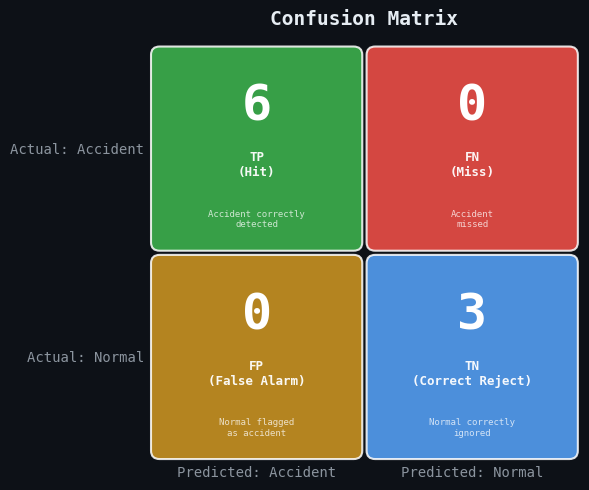

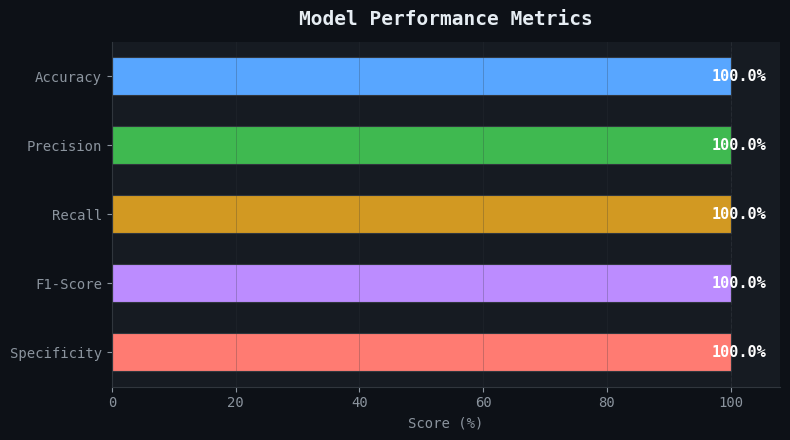

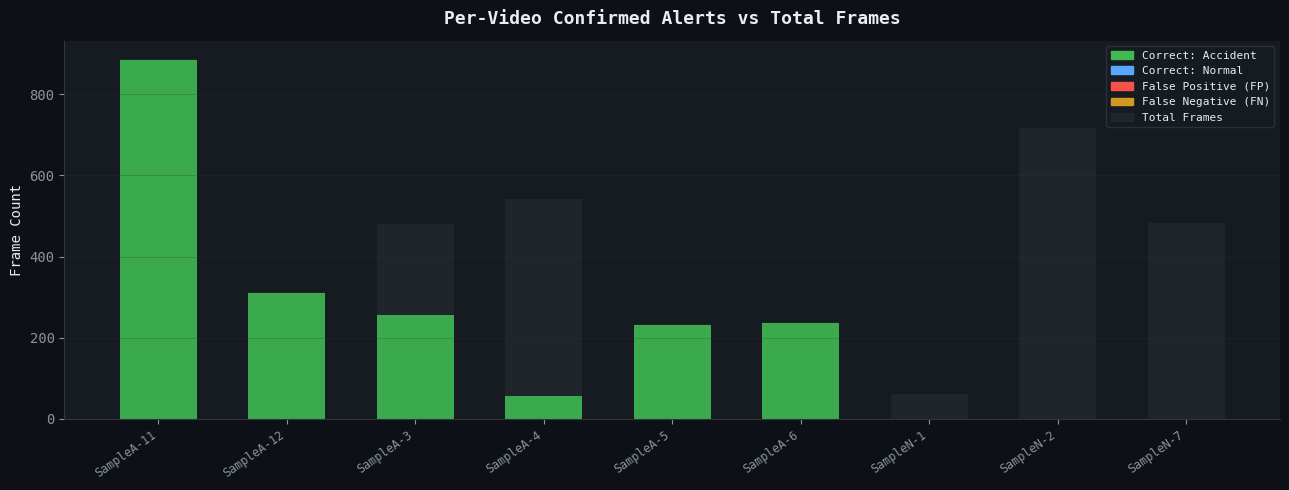

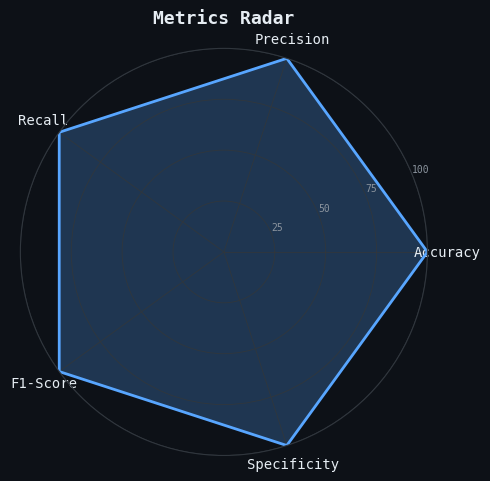

  ✔ All charts displayed.

✔ All outputs saved to: /content/outputs


In [ ]:
"""
╔══════════════════════════════════════════════════════════╗
║   Accident Detection System — Google Colab Edition v5    ║
║   + Confusion Matrix, Accuracy, Precision, Recall, F1    ║
║   + Visual Charts (plt.show display)                     ║
╚══════════════════════════════════════════════════════════╝
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import cv2
import numpy as np
from ultralytics import YOLO
from collections import deque
import time
import os
import glob
import json
from datetime import datetime

# ╔══════════════════════════════════════════════════════════╗
# ║              ★  CONFIGURE THESE  ★                      ║
# ╠══════════════════════════════════════════════════════════╣

MODEL_PATH   = "best.pt"

# Option A: one video
SINGLE_VIDEO = "/content/vid/SampleA-3.mp4"

# Option B: all videos in a folder (set to None to use Option A)
VIDEO_FOLDER = "/content/vid"
VIDEO_EXTS   = ("*.mp4", "*.avi", "*.mov", "*.mkv")

OUTPUT_DIR   = "/content/outputs"

# ╠══════════════════════════════════════════════════════════╣
# ║   GROUND TRUTH — set "accident" or "normal" per video   ║
# ║   (leave empty dict {} to skip metrics)                 ║
# ╠══════════════════════════════════════════════════════════╣
GROUND_TRUTH = {
    "SampleA-11.mp4": "accident",
    "SampleA-12.mp4": "accident",
    "SampleA-13.mp4": "accident",
    "SampleA-3.mp4":  "accident",
    "SampleA-4.mp4":  "accident",
    "SampleA-5.mp4":  "accident",
    "SampleA-6.mp4":  "accident",
    "SampleN-1.mp4":  "normal",
    "SampleN-10.mp4": "normal",
    "SampleN-2.mp4":  "normal",
    "SampleN-7.mp4":  "normal",
    "SampleN-8.mp4":  "normal",
    "SampleN-9.mp4":  "normal",
}

# ╠══════════════════════════════════════════════════════════╣
# ║              DETECTION TUNING                            ║
# ╠══════════════════════════════════════════════════════════╣
CONFIG = {
    "CONFIDENCE_THRESHOLD":     0.65,
    "TEMPORAL_WINDOW":          20,
    "TEMPORAL_RATIO_THRESHOLD": 0.55,
    "CONSECUTIVE_REQUIRED":     4,
    "ALERT_COOLDOWN_FRAMES":    45,
    "FLOW_HISTORY":             10,
    "MOTION_SPIKE_THRESHOLD":   5.0,
}
# ╚══════════════════════════════════════════════════════════╝


# ══════════════════════════════════════════════════════════
#  CHART PALETTE
# ══════════════════════════════════════════════════════════
BG      = "#0d1117"
PANEL   = "#161b22"
BORDER  = "#30363d"
ACCENT  = "#58a6ff"
GREEN   = "#3fb950"
RED     = "#f85149"
ORANGE  = "#d29922"
PURPLE  = "#bc8cff"
TEXT    = "#e6edf3"
SUBTEXT = "#8b949e"

plt.rcParams.update({
    "figure.facecolor": BG,    "axes.facecolor":  PANEL,
    "axes.edgecolor":   BORDER, "axes.labelcolor": TEXT,
    "xtick.color":      SUBTEXT,"ytick.color":     SUBTEXT,
    "text.color":       TEXT,   "font.family":     "monospace",
    "grid.color":       BORDER, "grid.linewidth":  0.6,
})


# ══════════════════════════════════════════════════════════
#  MOTION ANALYSER
# ══════════════════════════════════════════════════════════
class MotionAnalyzer:
    def __init__(self):
        self.prev_gray    = None
        self.flow_history = deque(maxlen=CONFIG["FLOW_HISTORY"])

    def compute(self, frame: np.ndarray) -> dict:
        gray = cv2.GaussianBlur(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), (5, 5), 0)
        if self.prev_gray is None:
            self.prev_gray = gray
            return {"mean_flow": 0.0, "is_spike": False, "spike_ratio": 1.0}

        flow = cv2.calcOpticalFlowFarneback(
            self.prev_gray, gray, None,
            pyr_scale=0.5, levels=3, winsize=15,
            iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
        self.prev_gray = gray

        mean_mag = float(np.mean(np.sqrt(flow[..., 0]**2 + flow[..., 1]**2)))
        self.flow_history.append(mean_mag)
        hist     = list(self.flow_history)
        baseline = np.mean(hist[:-1]) if len(hist) > 1 else mean_mag
        ratio    = mean_mag / (baseline + 1e-6)
        return {"mean_flow": mean_mag,
                "is_spike":  ratio >= CONFIG["MOTION_SPIKE_THRESHOLD"],
                "spike_ratio": ratio}

    def reset(self):
        self.prev_gray = None
        self.flow_history.clear()


# ══════════════════════════════════════════════════════════
#  TEMPORAL SMOOTHER
# ══════════════════════════════════════════════════════════
class TemporalSmoother:
    def __init__(self):
        self.window = deque(maxlen=CONFIG["TEMPORAL_WINDOW"])

    def update(self, is_accident: bool):
        self.window.append(1 if is_accident else 0)
        ratio = sum(self.window) / len(self.window) if self.window else 0.0
        ok = (len(self.window) >= CONFIG["CONSECUTIVE_REQUIRED"]
              and ratio >= CONFIG["TEMPORAL_RATIO_THRESHOLD"])
        return ok, ratio

    def reset(self):
        self.window.clear()


# ══════════════════════════════════════════════════════════
#  CONSECUTIVE COUNTER
# ══════════════════════════════════════════════════════════
class ConsecutiveCounter:
    def __init__(self):
        self.streak = 0

    def update(self, is_accident: bool) -> bool:
        self.streak = self.streak + 1 if is_accident else 0
        return self.streak >= CONFIG["CONSECUTIVE_REQUIRED"]

    def reset(self):
        self.streak = 0


# ══════════════════════════════════════════════════════════
#  ACCIDENT DETECTOR
# ══════════════════════════════════════════════════════════
class AccidentDetector:
    def __init__(self, model_path: str):
        print(f"[INFO] Loading model : {model_path}")
        self.model       = YOLO(model_path)
        self.class_names = self.model.names

        self.accident_id = next(
            (cid for cid, name in self.class_names.items() if "accident" in name.lower()),
            1)
        print(f"[INFO] Class map     : {self.class_names}")
        print(f"[INFO] Accident class: ID {self.accident_id} "
              f"→ '{self.class_names[self.accident_id]}'")
        print(f"[INFO] Conf threshold: {CONFIG['CONFIDENCE_THRESHOLD']}\n")

        self.motion      = MotionAnalyzer()
        self.smoother    = TemporalSmoother()
        self.consecutive = ConsecutiveCounter()
        self.alert_countdown    = 0
        self.accident_confirmed = False

    def _reset_state(self):
        self.motion.reset()
        self.smoother.reset()
        self.consecutive.reset()
        self.alert_countdown    = 0
        self.accident_confirmed = False

    def _classify(self, frame: np.ndarray):
        results = self.model(frame, verbose=False)
        if not results or results[0].probs is None:
            return False, 0.0, -1
        probs    = results[0].probs
        top_id   = int(probs.top1)
        acc_conf = float(probs.data.cpu().numpy()[self.accident_id])
        return ((top_id == self.accident_id
                 and acc_conf >= CONFIG["CONFIDENCE_THRESHOLD"]),
                acc_conf, top_id)

    def _decide(self, yolo_accident: bool, motion: dict):
        temporal_ok, ratio = self.smoother.update(yolo_accident)
        streak_ok          = self.consecutive.update(yolo_accident)
        if not yolo_accident:
            return False, f"Normal  (ratio={ratio:.2f})"
        if motion["is_spike"] and streak_ok:
            return True, f"YOLO+MotionSpike×{motion['spike_ratio']:.1f}+Streak"
        if temporal_ok:
            return True, f"YOLO+TemporalVote {ratio:.0%}"
        if streak_ok:
            return True, "YOLO+ConsecutiveStreak"
        return False, f"YOLO pending…  ratio={ratio:.2f}"

    def _draw(self, frame, confirmed, reason, acc_conf, top_id, motion):
        h, w = frame.shape[:2]
        if confirmed or self.alert_countdown > 0:
            overlay = frame.copy()
            cv2.rectangle(overlay, (0, 0), (w, 70), (0, 0, 180), -1)
            cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)
            cv2.putText(frame, "!! ACCIDENT DETECTED !!", (12, 50),
                        cv2.FONT_HERSHEY_DUPLEX, 1.3, (255, 255, 255), 2)
        else:
            cv2.rectangle(frame, (0, 0), (w, 50), (0, 140, 0), -1)
            cv2.putText(frame, f"No Accident  [{self.class_names.get(top_id, '?')}]",
                        (10, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)

        bar_y   = h - 43
        bar_w   = int(w * min(acc_conf, 1.0))
        bar_col = (0, 0, 220) if acc_conf > CONFIG["CONFIDENCE_THRESHOLD"] else (0, 180, 0)
        cv2.rectangle(frame, (0, bar_y),  (bar_w, bar_y + 7), bar_col,    -1)
        cv2.rectangle(frame, (0, bar_y),  (w,     bar_y + 7), (80, 80, 80), 1)

        cv2.rectangle(frame, (0, h - 35), (w, h), (20, 20, 20), -1)
        info = (f"AccConf:{acc_conf:.2f}  Flow:{motion['mean_flow']:.1f}  "
                f"Spike:{'Y' if motion['is_spike'] else 'N'}  {reason[:68]}")
        cv2.putText(frame, info, (5, h - 12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.40, (180, 180, 180), 1)
        return frame

    def run_video(self, video_path: str, output_path: str) -> dict:
        self._reset_state()
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"[ERROR] Cannot open: {video_path}")
            return None

        fps   = cap.get(cv2.CAP_PROP_FPS) or 30
        fw    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        fh    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        writer = cv2.VideoWriter(output_path,
                                 cv2.VideoWriter_fourcc(*"mp4v"),
                                 fps, (fw, fh))

        print(f"  Resolution : {fw}×{fh} @ {fps:.1f} FPS  ({total} frames)")
        print(f"  Output     : {output_path}")

        stats = {"frames": 0, "yolo_raw": 0, "confirmed": 0}
        t0 = time.time()

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            stats["frames"] += 1
            motion = self.motion.compute(frame)
            is_acc, acc_conf, top_id = self._classify(frame)

            if is_acc:
                stats["yolo_raw"] += 1

            confirmed, reason = self._decide(is_acc, motion)

            if confirmed:
                self.accident_confirmed = True
                self.alert_countdown    = CONFIG["ALERT_COOLDOWN_FRAMES"]
                stats["confirmed"] += 1
            else:
                if self.alert_countdown > 0:
                    self.alert_countdown -= 1
                else:
                    self.accident_confirmed = False

            writer.write(self._draw(frame, self.accident_confirmed,
                                    reason, acc_conf, top_id, motion))

            proc_fps = stats["frames"] / (time.time() - t0 + 1e-6)
            pct      = stats["frames"] / total * 100 if total > 0 else 0
            print(f"\r  [{pct:5.1f}%] {stats['frames']}/{total}  "
                  f"fps:{proc_fps:.1f}  raw:{stats['yolo_raw']}  "
                  f"confirmed:{stats['confirmed']}",
                  end="", flush=True)

        cap.release()
        writer.release()

        raw  = stats["yolo_raw"]
        conf = stats["confirmed"]
        fp   = raw - conf
        print(f"\n  ✔ Frames:{stats['frames']}  Raw:{raw}  "
              f"Filtered:{fp}  Confirmed:{conf}")

        # Video-level decision: accident if ≥5% of frames confirmed
        acc_ratio = conf / max(total, 1)
        stats["decision"] = "accident" if acc_ratio >= 0.05 else "normal"
        stats["total"]    = total
        return stats


# ══════════════════════════════════════════════════════════
#  METRICS CALCULATOR
# ══════════════════════════════════════════════════════════
def compute_metrics(results: list) -> dict:
    TP = FP = TN = FN = 0
    for r in results:
        gt   = GROUND_TRUTH.get(r["video"], "unknown")
        pred = r["decision"]
        r["gt"] = gt
        if   gt == "accident" and pred == "accident": TP += 1
        elif gt == "normal"   and pred == "accident": FP += 1
        elif gt == "normal"   and pred == "normal":   TN += 1
        elif gt == "accident" and pred == "normal":   FN += 1

    total = TP + FP + TN + FN
    acc   = (TP + TN) / total if total else 0
    prec  = TP / (TP + FP)   if (TP + FP) else 0
    rec   = TP / (TP + FN)   if (TP + FN) else 0
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
    spec  = TN / (TN + FP)   if (TN + FP) else 0
    fpr   = FP / (FP + TN)   if (FP + TN) else 0

    print(f"\n{'═'*68}")
    print(f"  {'Video':<28} {'GT':>10} {'Pred':>10} {'':>4}")
    print(f"  {'-'*60}")
    for r in results:
        match = "✔" if r.get("gt") == r["decision"] else "✘"
        print(f"  {r['video']:<28} {r.get('gt','?'):>10} {r['decision']:>10}  {match}")

    print(f"\n{'═'*68}")
    print(f"  Confusion Matrix  TP={TP}  FP={FP}  TN={TN}  FN={FN}")
    print(f"  Accuracy    : {acc*100:.1f}%")
    print(f"  Precision   : {prec*100:.1f}%")
    print(f"  Recall      : {rec*100:.1f}%")
    print(f"  F1-Score    : {f1*100:.1f}%")
    print(f"  Specificity : {spec*100:.1f}%")
    print(f"  FP Rate     : {fpr*100:.1f}%")
    print(f"{'═'*68}\n")

    return dict(TP=TP, FP=FP, TN=TN, FN=FN,
                accuracy=acc, precision=prec, recall=rec,
                f1=f1, specificity=spec, fpr=fpr)


# ══════════════════════════════════════════════════════════
#  VISUAL CHARTS  (plt.show — no HTML, no file save)
# ══════════════════════════════════════════════════════════

def plot_confusion_matrix(M: dict):
    fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
    ax.set_facecolor(BG)

    cm     = np.array([[M["TP"], M["FN"]], [M["FP"], M["TN"]]])
    labels = [["TP\n(Hit)", "FN\n(Miss)"],
              ["FP\n(False Alarm)", "TN\n(Correct Reject)"]]
    colors = [[GREEN, RED], [ORANGE, ACCENT]]
    descs  = [["Accident correctly\ndetected",  "Accident\nmissed"],
              ["Normal flagged\nas accident",    "Normal correctly\nignored"]]

    for i in range(2):
        for j in range(2):
            rect = mpatches.FancyBboxPatch(
                (j + 0.05, 1 - i + 0.05), 0.9, 0.9,
                boxstyle="round,pad=0.04",
                facecolor=colors[i][j], alpha=0.85,
                edgecolor="white", linewidth=1.5)
            ax.add_patch(rect)
            ax.text(j + 0.5, 1 - i + 0.70, str(cm[i, j]),
                    ha="center", va="center",
                    fontsize=36, fontweight="bold", color="white")
            ax.text(j + 0.5, 1 - i + 0.42, labels[i][j],
                    ha="center", va="center",
                    fontsize=9, color="white", alpha=0.95,
                    fontweight="bold")
            ax.text(j + 0.5, 1 - i + 0.16, descs[i][j],
                    ha="center", va="center",
                    fontsize=6.5, color="white", alpha=0.75)

    ax.set_xlim(0, 2); ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5]); ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(["Predicted: Accident", "Predicted: Normal"], fontsize=10)
    ax.set_yticklabels(["Actual: Normal", "Actual: Accident"],       fontsize=10)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title("Confusion Matrix", fontsize=14,
                 fontweight="bold", color=TEXT, pad=14)
    plt.tight_layout()
    plt.show()


def plot_metrics_bar(M: dict):
    names  = ["Accuracy", "Precision", "Recall", "F1-Score", "Specificity"]
    values = [M["accuracy"]*100, M["precision"]*100, M["recall"]*100,
              M["f1"]*100,       M["specificity"]*100]
    colors = [ACCENT, GREEN, ORANGE, PURPLE, "#ff7b72"]

    fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=BG)
    ax.set_facecolor(PANEL)
    bars = ax.barh(names, values, color=colors, height=0.55,
                   edgecolor=BORDER, linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(min(val + 1.5, 97), bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=11,
                fontweight="bold", color="white")

    ax.axvline(100, color=BORDER, linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xlim(0, 108)
    ax.set_xlabel("Score (%)", fontsize=10, color=SUBTEXT)
    ax.set_title("Model Performance Metrics", fontsize=14,
                 fontweight="bold", color=TEXT, pad=12)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_per_video(results: list):
    names     = [r["video"].replace(".mp4", "") for r in results]
    confirmed = [r["confirmed"] for r in results]
    frames    = [r.get("total", r.get("frames", 0)) for r in results]

    bar_colors = []
    for r in results:
        gt, pred = r.get("gt", "?"), r["decision"]
        if   gt == "accident" and pred == "accident": bar_colors.append(GREEN)
        elif gt == "normal"   and pred == "normal":   bar_colors.append(ACCENT)
        elif gt == "normal"   and pred == "accident": bar_colors.append(RED)
        else:                                          bar_colors.append(ORANGE)

    fig, ax = plt.subplots(figsize=(13, 5), facecolor=BG)
    ax.set_facecolor(PANEL)
    x = np.arange(len(names))
    ax.bar(x, frames,    color=BORDER,     alpha=0.4, width=0.6)
    ax.bar(x, confirmed, color=bar_colors, alpha=0.9, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=35, ha="right", fontsize=8.5)
    ax.set_ylabel("Frame Count", fontsize=10)
    ax.set_title("Per-Video Confirmed Alerts vs Total Frames",
                 fontsize=13, fontweight="bold", color=TEXT, pad=12)
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_patches = [
        mpatches.Patch(color=GREEN,  label="Correct: Accident"),
        mpatches.Patch(color=ACCENT, label="Correct: Normal"),
        mpatches.Patch(color=RED,    label="False Positive (FP)"),
        mpatches.Patch(color=ORANGE, label="False Negative (FN)"),
        mpatches.Patch(color=BORDER, alpha=0.4, label="Total Frames"),
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc="upper right",
              facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT)
    plt.tight_layout()
    plt.show()


def plot_radar(M: dict):
    cats   = ["Accuracy", "Precision", "Recall", "F1-Score", "Specificity"]
    vals   = [M["accuracy"], M["precision"], M["recall"], M["f1"], M["specificity"]]
    N      = len(cats)
    angles = [n / N * 2 * np.pi for n in range(N)] + [0]
    vals_p = [v * 100 for v in vals] + [vals[0] * 100]

    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), facecolor=BG)
    ax.set_facecolor(BG)
    ax.plot(angles, vals_p, color=ACCENT, linewidth=2)
    ax.fill(angles, vals_p, color=ACCENT, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), cats, fontsize=10, color=TEXT)
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(["25", "50", "75", "100"], fontsize=7, color=SUBTEXT)
    ax.grid(color=BORDER, linewidth=0.6)
    ax.spines["polar"].set_color(BORDER)
    ax.set_title("Metrics Radar", fontsize=13,
                 fontweight="bold", color=TEXT, pad=18)
    plt.tight_layout()
    plt.show()


def run_visual_metrics(results: list, M: dict):
    print(f"\n{'═'*58}")
    print("  GENERATING VISUAL METRICS")
    print(f"{'═'*58}")
    plot_confusion_matrix(M)
    plot_metrics_bar(M)
    plot_per_video(results)
    plot_radar(M)
    print("  ✔ All charts displayed.\n")


# ══════════════════════════════════════════════════════════
#  VIDEO COLLECTION
# ══════════════════════════════════════════════════════════
def collect_videos():
    if VIDEO_FOLDER:
        videos = []
        for ext in VIDEO_EXTS:
            videos += glob.glob(os.path.join(VIDEO_FOLDER, ext))
        videos.sort()
        if not videos:
            raise FileNotFoundError(f"No videos found in: {VIDEO_FOLDER}")
        return videos
    if not os.path.exists(SINGLE_VIDEO):
        raise FileNotFoundError(f"Video not found: {SINGLE_VIDEO}")
    return [SINGLE_VIDEO]


# ══════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════
if __name__ == "__main__":
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    videos   = collect_videos()
    detector = AccidentDetector(MODEL_PATH)

    print(f"\n{'═'*58}")
    print(f"  Processing {len(videos)} video(s)")
    print(f"{'═'*58}\n")

    all_results = []
    for i, vpath in enumerate(videos, 1):
        vname    = os.path.basename(vpath)
        out_path = os.path.join(OUTPUT_DIR,
                                os.path.splitext(vname)[0] + "_detected.mp4")
        print(f"[{i}/{len(videos)}] {vname}")
        stats = detector.run_video(vpath, out_path)
        if stats:
            stats["video"] = vname
            all_results.append(stats)
        print()

    # ── Summary table ─────────────────────────────
    print(f"\n{'═'*68}")
    print(f"  {'Video':<30} {'Frames':>7} {'RawDet':>7} {'Confirmed':>9} {'Decision':>10}")
    print(f"  {'-'*64}")
    for r in all_results:
        print(f"  {r['video']:<30} {r.get('total',0):>7} "
              f"{r['yolo_raw']:>7} {r['confirmed']:>9} {r['decision']:>10}")
    print(f"{'═'*68}")

    # ── Metrics + charts ──────────────────────────
    # Only evaluate videos that have a ground truth label
    labeled = [r for r in all_results if r["video"] in GROUND_TRUTH]
    if labeled:
        M = compute_metrics(labeled)

        # Save JSON summary
        json_path = os.path.join(OUTPUT_DIR, "metrics.json")
        with open(json_path, "w") as f:
            json.dump({**M, "results": labeled}, f, indent=2)
        print(f"  Metrics JSON → {json_path}")

        run_visual_metrics(labeled, M)
    else:
        print("\n  [INFO] No GROUND_TRUTH entries matched processed videos.")
        print("  Edit GROUND_TRUTH dict at top of script to enable metrics.\n")

    print(f"✔ All outputs saved to: {OUTPUT_DIR}")

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from collections import deque
import smtplib
from email.message import EmailMessage
import os

CONFIG = {
    "BASE_CONFIDENCE": 0.65,
    "HIGH_CONFIDENCE": 0.82,

    "TEMPORAL_WINDOW": 20,
    "TEMPORAL_RATIO_THRESHOLD": 0.6,

    "FLOW_HISTORY": 10,
    "MOTION_SPIKE_THRESHOLD": 3.5,

    "YOLO_WEIGHT": 0.65,
    "MOTION_WEIGHT": 0.15,
    "TEMPORAL_WEIGHT": 0.20,

    "ACCIDENT_SCORE_THRESHOLD": 0.60,
    "CONF_BUFFER_SIZE": 8,

    "VIDEO_ACCIDENT_RATIO": 0.10,

    "EMAIL_COOLDOWN_FRAMES": 90,


    "MIN_CONFIRM_FRAMES": 3,
}

MODEL_PATH = "best.pt"
VIDEO_PATH = "/content/SampleN-1.mp4"
OUTPUT_PATH = "/content/output.mp4"


EMAIL_CONFIG = {
    "SENDER": "deenmohai60@gmail.com",
    "PASSWORD": "dcmmdrxugdityvua",
    "RECEIVER": "mohamedshajith1906@gmail.com"
}


def send_email_alert(frame, score):
    """Send email with the BEST (highest-score) accident frame — not just the first."""
    try:
        img_path = "accident_best.jpg"


        annotated = frame.copy()
        cv2.putText(annotated, f"ACCIDENT  score:{score:.2f}", (20, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)
        cv2.imwrite(img_path, annotated)

        msg = EmailMessage()
        msg["Subject"] = f"ACCIDENT DETECTED  (score: {score:.2f})"
        msg["From"] = EMAIL_CONFIG["SENDER"]
        msg["To"] = EMAIL_CONFIG["RECEIVER"]
        msg.set_content(
            f"Accident detected with confidence score: {score:.2f}\n"
            "The attached image is the peak-confidence frame from the event."
        )

        with open(img_path, "rb") as f:
            msg.add_attachment(f.read(), maintype='image',
                               subtype='jpeg', filename="accident_best.jpg")

        with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
            server.login(EMAIL_CONFIG["SENDER"], EMAIL_CONFIG["PASSWORD"])
            server.send_message(msg)

        print(f"Email sent  (peak score: {score:.2f})")

    except Exception as e:
        print("Email error:", e)



class ConfidenceBuffer:
    def __init__(self):
        self.buffer = deque(maxlen=CONFIG["CONF_BUFFER_SIZE"])

    def update(self, conf):
        self.buffer.append(conf)
        return np.mean(self.buffer)


class MotionAnalyzer:
    def __init__(self):
        self.prev = None
        self.hist = deque(maxlen=CONFIG["FLOW_HISTORY"])

    def compute(self, frame):

        small = cv2.resize(frame, (320, 180))
        gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

        if self.prev is None:
            self.prev = gray
            return {"spike": False, "ratio": 1.0, "magnitude": 0.0}

        flow = cv2.calcOpticalFlowFarneback(
            self.prev, gray, None, 0.5, 3, 15, 3, 5, 1.2, 0
        )
        self.prev = gray

        mag = np.mean(np.sqrt(flow[..., 0] ** 2 + flow[..., 1] ** 2))
        self.hist.append(mag)

        baseline = np.median(self.hist) if len(self.hist) > 2 else mag
        ratio = mag / (baseline + 1e-6)

        return {
            "spike": ratio > CONFIG["MOTION_SPIKE_THRESHOLD"],
            "ratio": ratio,
            "magnitude": mag
        }


class Temporal:
    def __init__(self):
        self.window = deque(maxlen=CONFIG["TEMPORAL_WINDOW"])

    def update(self, val):
        self.window.append(1 if val else 0)
        return sum(self.window) / len(self.window)

class PeakFrameTracker:
    """
    Keeps the single frame with the highest accident score.
    This ensures the email shows the clearest accident frame,
    not just the first frame that crossed the threshold.
    """
    def __init__(self):
        self.best_frame = None
        self.best_score = 0.0
        self.frames_since_sent = 999
    def update(self, frame, score):
        if score > self.best_score:
            self.best_score = score
            self.best_frame = frame.copy()

    def should_send(self):
        cooldown_ok = self.frames_since_sent >= CONFIG["EMAIL_COOLDOWN_FRAMES"]
        has_frame = self.best_frame is not None
        strong_signal = self.best_score >= 0.75
        return cooldown_ok and has_frame and strong_signal

    def mark_sent(self):
        self.frames_since_sent = 0
        self.best_frame = None
        self.best_score = 0.0

    def tick(self):
        self.frames_since_sent += 1


class Detector:
    def __init__(self):
        self.model = YOLO(MODEL_PATH)
        self.motion = MotionAnalyzer()
        self.temp = Temporal()
        self.buffer = ConfidenceBuffer()
        self.peak_tracker = PeakFrameTracker()

        self.acc_id = 1

        self.consecutive_detections = 0

    def classify(self, frame):
        r = self.model(frame, verbose=False)[0]

        if r.probs is None:
            return False, 0.0

        conf = float(r.probs.data[self.acc_id])
        conf = self.buffer.update(conf)


        thresh = CONFIG["BASE_CONFIDENCE"]
        if conf > CONFIG["HIGH_CONFIDENCE"]:
            thresh = 0.58

        return conf >= thresh, conf

    def decide(self, yolo, motion, temp_ratio):
        y = 1.0 if yolo else 0.0

        m = min(motion["ratio"] / CONFIG["MOTION_SPIKE_THRESHOLD"], 1.0)
        t = temp_ratio

        score = (
            CONFIG["YOLO_WEIGHT"] * y +
            CONFIG["MOTION_WEIGHT"] * m +
            CONFIG["TEMPORAL_WEIGHT"] * t
        )

        return score >= CONFIG["ACCIDENT_SCORE_THRESHOLD"], score

    def run(self):
        cap = cv2.VideoCapture(VIDEO_PATH)

        if not cap.isOpened():
            print(f"Cannot open video: {VIDEO_PATH}")
            return

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        print(f"Video loaded — {total_frames} frames")

        w = int(cap.get(3))
        h = int(cap.get(4))
        fps = cap.get(5)

        out = cv2.VideoWriter(
            OUTPUT_PATH,
            cv2.VideoWriter_fourcc(*'mp4v'),
            fps, (w, h)
        )

        total = confirmed = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            total += 1
            self.peak_tracker.tick()

            yolo, conf = self.classify(frame)
            motion = self.motion.compute(frame)
            temp_ratio = self.temp.update(yolo)

            decision, score = self.decide(yolo, motion, temp_ratio)

            if decision:

                self.consecutive_detections += 1
                confirmed_accident = self.consecutive_detections >= CONFIG["MIN_CONFIRM_FRAMES"]

                if confirmed_accident:
                    confirmed += 1
                    self.peak_tracker.update(frame, score)


                    cv2.putText(frame, "ACCIDENT", (20, 50),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

                    if self.peak_tracker.should_send():
                        send_email_alert(
                            self.peak_tracker.best_frame,
                            self.peak_tracker.best_score
                        )
                        self.peak_tracker.mark_sent()
                else:

                    cv2.putText(frame, "Detecting...", (20, 50),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 165, 255), 2)
            else:

                self.consecutive_detections = 0


            cv2.putText(frame, f"YOLO:{conf:.2f}  Score:{score:.2f}",
                        (20, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.55,
                        (255, 255, 255), 2)

            out.write(frame)

        cap.release()
        out.release()

        ratio = confirmed / max(total, 1)
        if confirmed < 10:
            ratio *= 0.5

        final = "ACCIDENT" if ratio >= CONFIG["VIDEO_ACCIDENT_RATIO"] else "NORMAL"

        print("\n========= RESULT =========")
        print(f"Frames   : {total}")
        print(f"Confirmed: {confirmed}")
        print(f"Ratio    : {ratio:.3f}")
        print(f"Decision : {final}")


if __name__ == "__main__":
    detector = Detector()
    detector.run()

Video loaded — 480 frames
Email sent  (peak score: 0.89)
Email sent  (peak score: 0.94)
Email sent  (peak score: 0.93)

========= RESULT =========
Frames   : 480
Confirmed: 259
Ratio    : 0.540
Decision : ACCIDENT


Frame:1  Mag:0.00  Ratio:1.00
Frame:2  Mag:1.03  Ratio:1.00
Frame:3  Mag:1.30  Ratio:1.00
Frame:4  Mag:1.90  Ratio:1.46
Frame:5  Mag:2.34  Ratio:1.47
Frame:6  Mag:2.04  Ratio:1.08
Frame:7  Mag:2.06  Ratio:1.05
Frame:8  Mag:1.81  Ratio:0.95
Frame:9  Mag:1.49  Ratio:0.80
Frame:10  Mag:1.71  Ratio:0.95
Frame:11  Mag:1.59  Ratio:0.90
Frame:12  Mag:1.57  Ratio:0.89
Frame:13  Mag:1.37  Ratio:0.78
Frame:14  Mag:0.65  Ratio:0.39
Frame:15  Mag:0.29  Ratio:0.19
Frame:16  Mag:0.20  Ratio:0.13
Frame:17  Mag:0.16  Ratio:0.11
Frame:18  Mag:0.18  Ratio:0.17
Frame:19  Mag:0.19  Ratio:0.41
Frame:20  Mag:0.21  Ratio:0.84
Frame:21  Mag:0.24  Ratio:1.06
Frame:22  Mag:0.29  Ratio:1.28
Frame:23  Mag:0.34  Ratio:1.50
Frame:24  Mag:0.40  Ratio:1.75
Frame:25  Mag:0.55  Ratio:2.42
Frame:26  Mag:0.65  Ratio:2.43
Frame:27  Mag:0.79  Ratio:2.48
Frame:28  Mag:0.87  Ratio:2.34
Frame:29  Mag:1.02  Ratio:2.14
Frame:30  Mag:1.14  Ratio:1.88
Frame:31  Mag:1.32  Ratio:1.83
Frame:32  Mag:1.25  Ratio:1.51
Frame:33  Mag:1.2

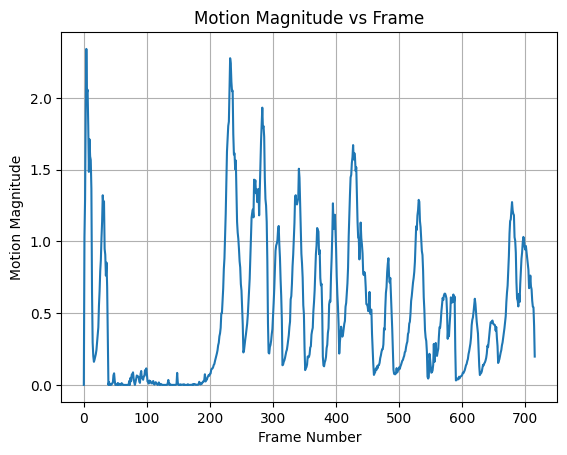


===== RESULT =====
Frames: 716
Confirmed: 0
Decision: NORMAL


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from collections import deque
import smtplib
from email.message import EmailMessage
import matplotlib.pyplot as plt

# ================= CONFIG =================
CONFIG = {
    "BASE_CONFIDENCE": 0.65,
    "HIGH_CONFIDENCE": 0.82,
    "TEMPORAL_WINDOW": 20,
    "FLOW_HISTORY": 10,
    "MOTION_SPIKE_THRESHOLD": 3.5,
    "YOLO_WEIGHT": 0.65,
    "MOTION_WEIGHT": 0.15,
    "TEMPORAL_WEIGHT": 0.20,
    "ACCIDENT_SCORE_THRESHOLD": 0.60,
    "CONF_BUFFER_SIZE": 8,
    "VIDEO_ACCIDENT_RATIO": 0.10,
    "EMAIL_COOLDOWN_FRAMES": 90,
    "MIN_CONFIRM_FRAMES": 3,
}

MODEL_PATH = "/content/best.pt"
VIDEO_PATH = "/content/SampleN-2.mp4"
OUTPUT_PATH = "output_with_flow.mp4"

EMAIL_CONFIG = {
    "SENDER": "your_email@gmail.com",
    "PASSWORD": "your_app_password",
    "RECEIVER": "receiver@gmail.com"
}

# ================= EMAIL =================
def send_email_alert(frame, score):
    try:
        img_path = "accident_best.jpg"
        annotated = frame.copy()
        cv2.putText(annotated, f"ACCIDENT score:{score:.2f}",
                    (20, 50), cv2.FONT_HERSHEY_SIMPLEX,
                    1.0, (0, 0, 255), 2)
        cv2.imwrite(img_path, annotated)

        msg = EmailMessage()
        msg["Subject"] = f"ACCIDENT DETECTED (score: {score:.2f})"
        msg["From"] = EMAIL_CONFIG["SENDER"]
        msg["To"] = EMAIL_CONFIG["RECEIVER"]
        msg.set_content("Accident detected. See attached image.")

        with open(img_path, "rb") as f:
            msg.add_attachment(f.read(),
                               maintype='image',
                               subtype='jpeg',
                               filename="accident.jpg")

        with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
            server.login(EMAIL_CONFIG["SENDER"], EMAIL_CONFIG["PASSWORD"])
            server.send_message(msg)

        print(" Email Sent")

    except Exception as e:
        print("Email Error:", e)

# ================= FLOW VISUAL =================
def visualize_flow(frame, flow):
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    # 🔥 REMOVE NOISE (very important)
    mag[mag < 1.0] = 0   # filter small motion

    # 🔥 STRONG NORMALIZATION
    mag_norm = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

    # 🔥 APPLY COLOR MAP (better than HSV)
    heatmap = cv2.applyColorMap(mag_norm.astype(np.uint8), cv2.COLORMAP_JET)

    return heatmap, np.mean(mag)
# ================= MODULES =================
class ConfidenceBuffer:
    def __init__(self):
        self.buffer = deque(maxlen=CONFIG["CONF_BUFFER_SIZE"])

    def update(self, conf):
        self.buffer.append(conf)
        return np.mean(self.buffer)

class MotionAnalyzer:
    def __init__(self):
        self.prev = None
        self.hist = deque(maxlen=CONFIG["FLOW_HISTORY"])

    def compute(self, frame):
        small = cv2.resize(frame, (320, 180))
        gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

        if self.prev is None:
            self.prev = gray
            return {"spike": False, "ratio": 1.0, "mag": 0.0, "flow_vis": frame}

        flow = cv2.calcOpticalFlowFarneback(
            self.prev, gray, None,
            0.5, 3, 15, 3, 5, 1.2, 0
        )
        self.prev = gray

        flow_vis, mag = visualize_flow(small, flow)
        flow_vis = cv2.resize(flow_vis, (frame.shape[1], frame.shape[0]))

        self.hist.append(mag)
        baseline = np.median(self.hist) if len(self.hist) > 2 else mag
        ratio = mag / (baseline + 1e-6)

        return {
            "spike": ratio > CONFIG["MOTION_SPIKE_THRESHOLD"],
            "ratio": ratio,
            "mag": mag,
            "flow_vis": flow_vis
        }

class Temporal:
    def __init__(self):
        self.window = deque(maxlen=CONFIG["TEMPORAL_WINDOW"])

    def update(self, val):
        self.window.append(1 if val else 0)
        return sum(self.window) / len(self.window)

class PeakFrameTracker:
    def __init__(self):
        self.best_frame = None
        self.best_score = 0.0
        self.frames_since_sent = 999

    def update(self, frame, score):
        if score > self.best_score:
            self.best_score = score
            self.best_frame = frame.copy()

    def should_send(self):
        return (self.frames_since_sent >= CONFIG["EMAIL_COOLDOWN_FRAMES"]
                and self.best_frame is not None
                and self.best_score >= 0.75)

    def mark_sent(self):
        self.frames_since_sent = 0
        self.best_frame = None
        self.best_score = 0.0

    def tick(self):
        self.frames_since_sent += 1

# ================= DETECTOR =================
class Detector:
    def __init__(self):
        self.model = YOLO(MODEL_PATH)
        self.motion = MotionAnalyzer()
        self.temp = Temporal()
        self.buffer = ConfidenceBuffer()
        self.peak = PeakFrameTracker()

        self.acc_id = 1
        self.consecutive = 0

    def classify(self, frame):
        r = self.model(frame, verbose=False)[0]
        if r.probs is None:
            return False, 0.0

        conf = float(r.probs.data[self.acc_id])
        conf = self.buffer.update(conf)

        thresh = CONFIG["BASE_CONFIDENCE"]
        if conf > CONFIG["HIGH_CONFIDENCE"]:
            thresh = 0.58

        return conf >= thresh, conf

    def decide(self, yolo, motion, temp_ratio):
        y = 1.0 if yolo else 0.0
        m = min(motion["ratio"] / CONFIG["MOTION_SPIKE_THRESHOLD"], 1.0)
        t = temp_ratio

        score = (
            CONFIG["YOLO_WEIGHT"] * y +
            CONFIG["MOTION_WEIGHT"] * m +
            CONFIG["TEMPORAL_WEIGHT"] * t
        )

        return score >= CONFIG["ACCIDENT_SCORE_THRESHOLD"], score

    def run(self):
        cap = cv2.VideoCapture(VIDEO_PATH)

        w = int(cap.get(3))
        h = int(cap.get(4))
        fps = cap.get(5)

        out = cv2.VideoWriter(
            OUTPUT_PATH,
            cv2.VideoWriter_fourcc(*'mp4v'),
            fps, (w, h)
        )

        total = confirmed = 0
        motion_values = []

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            total += 1
            self.peak.tick()

            yolo, conf = self.classify(frame)
            motion = self.motion.compute(frame)
            temp_ratio = self.temp.update(yolo)

            decision, score = self.decide(yolo, motion, temp_ratio)

            motion_values.append(motion["mag"])

            overlay = cv2.addWeighted(frame, 0.7, motion["flow_vis"], 0.3, 0)

            # ===== SAVE IMAGES FOR REPORT =====
            if total == 50:
                cv2.imwrite("raw_frame.jpg", frame)
                cv2.imwrite("flow_heatmap.jpg", motion["flow_vis"])
                cv2.imwrite("annotated_output.jpg", overlay)

            # Debugging print statement, moved inside the loop
            print(f"Frame:{total}  Mag:{motion['mag']:.2f}  Ratio:{motion['ratio']:.2f}")

            if decision:
                self.consecutive += 1
                if self.consecutive >= CONFIG["MIN_CONFIRM_FRAMES"]:
                    confirmed += 1
                    self.peak.update(frame, score)

                    cv2.putText(overlay, "ACCIDENT", (20, 50),
                                cv2.FONT_HERSHEY_SIMPLEX, 1,
                                (0, 0, 255), 3)

                    if self.peak.should_send():
                        send_email_alert(self.peak.best_frame,
                                         self.peak.best_score)
                        self.peak.mark_sent()
            else:
                self.consecutive = 0

            cv2.putText(overlay,
                        f"YOLO:{conf:.2f} Score:{score:.2f} Motion:{motion['ratio']:.2f}",
                        (20, 90),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (255, 255, 255), 2)

            out.write(overlay)

        cap.release()
        out.release()

        # ===== GRAPH =====
        plt.figure()
        plt.plot(motion_values)
        plt.xlabel("Frame Number")
        plt.ylabel("Motion Magnitude")
        plt.title("Motion Magnitude vs Frame")
        plt.grid()
        plt.savefig("motion_graph.png")
        plt.show()

        ratio = confirmed / max(total, 1)
        final = "ACCIDENT" if ratio >= CONFIG["VIDEO_ACCIDENT_RATIO"] else "NORMAL"

        print("\n===== RESULT =====")
        print("Frames:", total)
        print("Confirmed:", confirmed)
        print("Decision:", final)

# ================= RUN =================
if __name__ == "__main__":
    Detector().run()
